<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-03-07 06:30:51--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
169.63.118.104ourses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  43.0MB/s    in 4.8s    

2026-03-07 06:30:56 (42.1 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


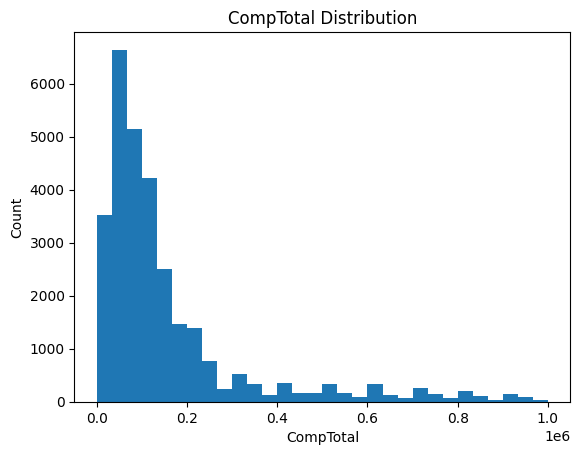

In [11]:
## Write your code here
QUERY = """SELECT CompTotal from main"""

df = pd.read_sql(QUERY, conn)

df = df[df['CompTotal'] < 1000000] 

plt.hist(df['CompTotal'], bins = 30)
plt.title('CompTotal Distribution')
plt.xlabel('CompTotal')
plt.ylabel('Count')
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


In [20]:
df['YearsCodePro'].value_counts()

YearsCodePro
2     4168
3     4093
5     3526
10    3251
4     3215
0     2856
6     2843
1     2639
8     2549
7     2517
12    1777
15    1635
20    1549
9     1493
11    1312
13    1127
14    1082
25     998
16     946
18     867
17     814
30     689
24     632
19     516
22     492
23     448
26     426
27     380
21     380
28     342
35     285
29     196
32     194
40     194
34     169
38     134
33     132
36     119
31     106
37     104
45      56
42      55
39      54
41      51
51      50
44      42
43      37
46      21
50      14
48      14
49      11
47      10
Name: count, dtype: int64

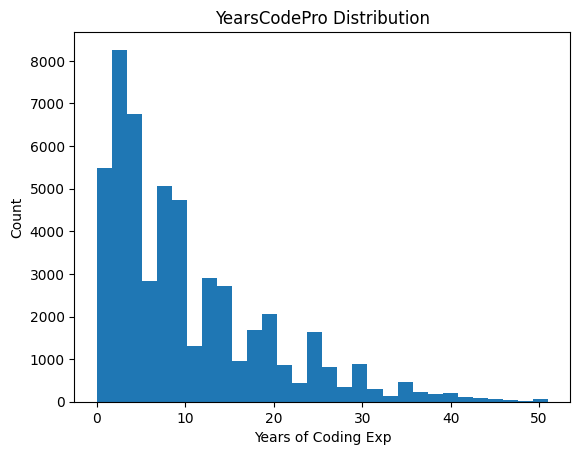

In [22]:
## Write your code here
QUERY = """SELECT YearsCodePro from main"""

df = pd.read_sql(QUERY, conn)


df['YearsCodePro'] = df['YearsCodePro'].replace({'Less than 1 year':0,'More than 50 years':51})
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors = 'coerce')

plt.hist(df['YearsCodePro'], bins = 30)
plt.title('YearsCodePro Distribution')
plt.xlabel('Years of Coding Exp')
plt.ylabel('Count')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


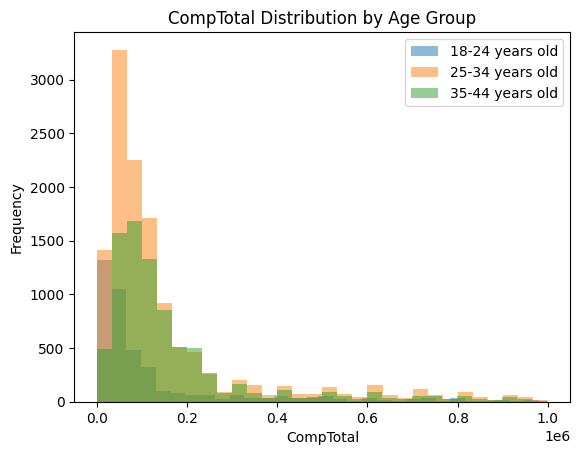

In [24]:
## Write your code here
QUERY = """SELECT Age, CompTotal FROM main"""
df = pd.read_sql(QUERY, conn)

# remove missing values
df = df.dropna(subset=['CompTotal'])
df = df[df['CompTotal']<1000000]

# select some age groups
age_groups = ['18-24 years old', '25-34 years old', '35-44 years old']

for age in age_groups:
    subset = df[df['Age'] == age]
    plt.hist(subset['CompTotal'], bins=30, alpha=0.5, label=age)

plt.title("CompTotal Distribution by Age Group")
plt.xlabel("CompTotal")
plt.ylabel("Frequency")
plt.legend()

plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


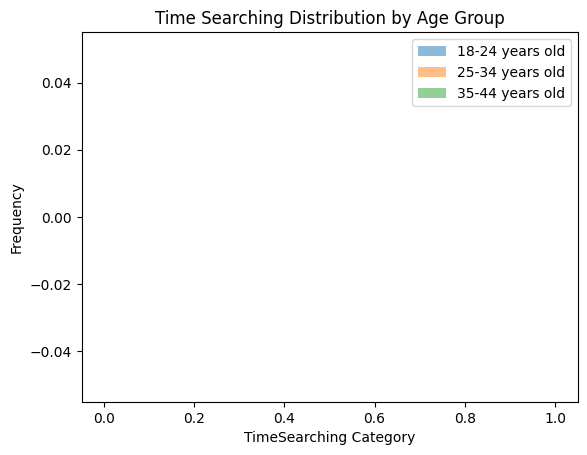

In [27]:
## Write your code here
QUERY = """SELECT Age, TimeSearching FROM main"""
df = pd.read_sql(QUERY, conn)

time_map = {
    'Less than 15 minutes': 1,
    '15-30 minutes': 2,
    '30-60 minutes': 3,
    '60-120 minutes': 4,
    'Over 120 minutes': 5
}

df['TimeSearching'] = df['TimeSearching'].map(time_map)

df['TimeSearching'] = df['TimeSearching'].map(time_map)

age_groups = ['18-24 years old', '25-34 years old', '35-44 years old']

for age in age_groups:
    subset = df[df['Age'] == age]
    plt.hist(subset['TimeSearching'].dropna(), bins=5, alpha=0.5, label=age)

plt.title("Time Searching Distribution by Age Group")
plt.xlabel("TimeSearching Category")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


In [ ]:
## Write your code here

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


In [ ]:
## Write your code here

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


In [ ]:
## Write your code here

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [ ]:
## Write your code here

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
